In [1]:
import warnings
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import scanpy as sc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scanpy as sc
import os

import matplotlib as mpl
# enables correct plotting of text
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42 

import kktk

In [2]:
import session_info
session_info.show()

In [3]:
sc.settings.set_figure_params(dpi=80)

# Function

In [4]:
# https://cell2location.readthedocs.io/en/latest/notebooks/cell2location_short_demo.html
def select_slide(adata, s, s_col='sample'):
    r""" This function selects the data for one slide from the spatial anndata object.

    :param adata: Anndata object with multiple spatial experiments
    :param s: name of selected experiment
    :param s_col: column in adata.obs listing experiment name for each location
    """

    slide = adata[adata.obs[s_col].isin([s]), :]
    s_keys = list(slide.uns['spatial'].keys())
    s_spatial = np.array(s_keys)[[s in k for k in s_keys]][0]

    slide.uns['spatial'] = {s_spatial: slide.uns['spatial'][s_spatial]}

    return slide

import seaborn as sns
import matplotlib.pyplot as plt


In [32]:
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.anchored_artists import AnchoredSizeBar
import matplotlib.font_manager as fm

def add_spatial_scalebar(
    ax,
    adata,
    library_id,
    img_key,
    bar_um=500,
    label=None,
    loc='lower right',
    pad=0.3,
    color='black',
    frameon=False,
    size_vertical=8,
    font_size=10,
):
    """
    Add a scale bar to a Scanpy spatial plot.

    Parameters
    ----------
    ax : matplotlib axis
        Axis returned/used by sc.pl.spatial.
    adata : AnnData
        AnnData containing .uns['spatial'].
    library_id : str
        Library key in adata.uns['spatial'].
    img_key : str
        Image key used in sc.pl.spatial, e.g. '0.3_mpp_150_buffer'.
    bar_um : float
        Desired scale bar length in micrometers.
    label : str or None
        Label to display. If None, uses e.g. '500 µm'.
    """
    spatial_info = adata.uns["spatial"][library_id]

    # microns per pixel for the plotted image
    # assuming your img_key name contains something like 0.3_mpp = 0.3 microns/pixel
    # best case: store/read this explicitly if available
    if "mpp" in img_key:
        # example: "0.3_mpp_150_buffer" -> 0.3
        mpp = float(img_key.split("_mpp")[0])
    else:
        raise ValueError(
            f"Could not infer microns-per-pixel from img_key='{img_key}'. "
            "Please provide it explicitly."
        )

    bar_px = bar_um / mpp

    if label is None:
        label = f"{int(bar_um)} µm"

    fontprops = fm.FontProperties(size=font_size)

    scalebar = AnchoredSizeBar(
        ax.transData,
        bar_px,
        label,
        loc=loc,
        pad=pad,
        color=color,
        frameon=frameon,
        size_vertical=size_vertical,
        fontproperties=fontprops,
    )
    ax.add_artist(scalebar)

# Variables

In [5]:
figdir = '/rfs/project/rfs-iCNyzSAaucw/kk837/notebooks/Foetal/Revision_Oct2025/fetal_ms_figures'

In [6]:
data_object_dir = '/rfs/project/rfs-iCNyzSAaucw/kk837/data_objects/Foetal/VisiumHD/Revision_Oct2025'
path_adata = f'{data_object_dir}/all_b2c_cells_filtered_raw.h5ad'

# data which have aligned niches
path_adata_niches = '/rfs/project/rfs-iCNyzSAaucw/kk837/data_objects/Foetal/TissueTypist/adata_for_training/adata_hd_raw.h5ad'

# Read in adata

In [8]:
adata = sc.read_h5ad(path_adata)
adata

AnnData object with n_obs × n_vars = 225097 × 18085
    obs: 'object_id', 'bin_count', 'array_row', 'array_col', 'labels_joint_source', 'in_tissue_manual', 'library', 'donor_section_ID', 'per-frame_donorIDs', 'donor', 'CS', 'est_CS', 'GA', 'PCW', 'section_ID', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'library_donor', 'n_genes', 'scVI_latent_n-layers-3_leiden_0.2', 'scVI_latent_n-layers-3_leiden_0.3', 'scVI_latent_n-layers-3_leiden_0.4', 'scVI_latent_n-layers-3_leiden_0.5', 'scVI_latent_n-layers-3_leiden_0.8', 'scVI_latent_n-layers-3_leiden_1.0', 'scVI_latent_n-layers-3_leiden_1.5', 'scVI_latent_n-layers-3_leiden_2.0', 'scVI_latent_n-layers-3_leiden_3.0', 'scVI_latent_n-layers-3_leiden_4.0', 'coarse_grain_pre', 'coarse_grain_pre_2', 'coarse_grain_tacco_ref-hd-sc

In [9]:
print(adata.X.data[:10])

[1. 1. 1. 1. 1. 1. 1. 2. 1. 1.]


In [10]:
# add alighned niches
ad = sc.read_h5ad(path_adata_niches,backed='r')

adata.obs[['niche_coarse_Mar2026','niche_fine_Mar2026']] = ad.obs[['niche_coarse_Mar2026','niche_fine_Mar2026']].reindex(adata.obs_names).copy()
adata.shape

(225097, 18085)

In [14]:
adata.obs['niche_fine_Mar2026'].isna().sum()

np.int64(9184)

In [15]:
adata.obs['niche_coarse_Mar2026'] = adata.obs['niche_coarse_Mar2026'].astype('str')
adata.obs['niche_fine_Mar2026'] = adata.obs['niche_fine_Mar2026'].astype('str')
adata.obs['niche_coarse_Mar2026'].fillna('nan',inplace=True)
adata.obs['niche_fine_Mar2026'].fillna('nan',inplace=True)

In [16]:
adata.obs[['niche_coarse_Mar2026','niche_fine_Mar2026']].head()

,niche_coarse_Mar2026,niche_fine_Mar2026
HEA_FOET14880396___1,Vasculature,Coronary vessel
HEA_FOET14880396___2,Vasculature,Coronary vessel
HEA_FOET14880396___3,Vasculature,Coronary vessel
HEA_FOET14880396___4,nan,nan
HEA_FOET14880396___5,Epicardium,Epicardium


# Coordinates for cropping each section

In [14]:
crop_coords = {
    'HEA_FOET14880396__C194__1':None,
    'CellTalkHHD_Human_13_BRC2757-2758-7__BRC2757__1':(-1000, 19000, 11000, 27000),
    'CellTalkHHD_Human_13_BRC2757-2758-7__BRC2757__2':(28000, 49000, -1000, 19000),
    'CellTalkHHD_Human_13_BRC2757-2758-7__BRC2758__1':(-1000, 20000, -1000, 12000),
    'CellTalkHHD_Human_13_BRC2757-2758-7__BRC2758__2':(28000, 49000, 18000, 33000),
}
section_list = list(crop_coords.keys())

# Add mapped histological annotations

In [18]:
c194_annot = pd.read_csv('./mapped_loupe_annotations/HEA_FOET14880396_HistologicalAnnotation_mapped-obs.csv',
                         index_col=0)
c194_annot.index = 'HEA_FOET14880396___'+c194_annot.index.astype('str')
display(c194_annot.head())

brc_annot = pd.read_csv('./mapped_loupe_annotations/CellTalkHHD_Human_13_BRC2757-2758-7_HistologicalAnnotation_mapped-obs.csv',
                         index_col=0)
brc_annot.index = 'CellTalkHHD_Human_13_BRC2757-2758-7___'+brc_annot.index.astype('str')
display(brc_annot.head())

,object_id,bin_count,array_row,array_col,labels_joint_source,in_tissue_manual,HistologicalAnnotation
HEA_FOET14880396___1,1,31,2932.612903,334.000000,primary,tissue,non-cardiac tissue
HEA_FOET14880396___2,2,26,2959.346154,336.923077,primary,tissue,non-cardiac tissue
HEA_FOET14880396___3,3,32,2882.562500,334.187500,primary,tissue,non-cardiac tissue
HEA_FOET14880396___4,4,28,2862.250000,515.178571,primary,tissue,non-cardiac tissue
HEA_FOET14880396___5,5,35,2870.714286,305.171429,primary,tissue,non-cardiac tissue


,object_id,bin_count,array_row,array_col,labels_joint_source,in_tissue_manual,donor_section_ID,HistologicalAnnotation
CellTalkHHD_Human_13_BRC2757-2758-7___1,1,35,2528.285714,284.828571,primary,no_tissue,BRC2758__1,Atrium - right
CellTalkHHD_Human_13_BRC2757-2758-7___2,2,37,2456.243243,177.810811,primary,tissue,BRC2758__1,Atrium - right
CellTalkHHD_Human_13_BRC2757-2758-7___3,3,23,2387.739130,290.826087,primary,tissue,BRC2758__1,Atrium
CellTalkHHD_Human_13_BRC2757-2758-7___4,4,31,2701.000000,511.387097,primary,no_tissue,BRC2758__1,Atrium - right
CellTalkHHD_Human_13_BRC2757-2758-7___5,5,18,2591.888889,215.666667,primary,no_tissue,BRC2758__1,Atrium - right


In [19]:
shared = list(set(adata.obs_names).intersection(c194_annot.index))
print(len(shared))
adata.obs.loc[shared,'HistologicalAnnotation']=c194_annot.loc[shared,'HistologicalAnnotation']

shared = list(set(adata.obs_names).intersection(brc_annot.index))
print(len(shared))
adata.obs.loc[shared,'HistologicalAnnotation']=brc_annot.loc[shared,'HistologicalAnnotation']

141884
83213


In [20]:
adata.obs['HistologicalAnnotation'].fillna('no_annotation',inplace=True)

# Set category and save

In [23]:
# set category - predicted niches
adata.obs['niche_coarse_Mar2026'] = (
    adata.obs['niche_coarse_Mar2026']
    .astype('category')
    .cat.reorder_categories([
        'Atrium',
        'Pacemaker conduction system',
        'AV junction',
        'Ventricle',
        'Vasculature',
        'Epicardium',
        'nan'
    ], ordered=True))

adata.obs['niche_fine_Mar2026'] = (
    adata.obs['niche_fine_Mar2026']
    .astype('category')
    .cat.reorder_categories([
        'Atrium - Left',
        'Atrium - Right',
        'Atrium - Transitional',
        'Sinus horn',
        'SA node - Head',
        'SA node - Tail',
        'AV node',
        'Endocardial cushion - Valve',
        'Ventricle - Compact',
        'Ventricle - Trabeculated',
        'VCS - Proximal',
        'VCS - Distal',
        'Endocardium - Ventricular',
        'Great vessel',
        'Ductus arteriosus',
        'Coronary vessel',
        'Connective tissue',
        'Epicardium',
        'nan'
    ], ordered=True))

In [24]:
# set category - histological annotations
adata.obs['HistologicalAnnotation'] = (
    adata.obs['HistologicalAnnotation']
    .astype('category')
    .cat.reorder_categories([
        'Atrium - left',
        'Atrium - right',
        'Atrium',
        'AV junctional region',
        'Valves',
        'Ventricle - outer',
        'Ventricle - inner',
        'Ventricle',
        'Great vessel - Aorta',
        'Great vessel - Pulmonary artery Right',
        'Great vessel - Pulmonary artery Left and Ductus arteriosus',
        'Vena cava',
        'Coronary vessel',
        'Connective tissue',
        'non-cardiac tissue',
        'no_annotation'
    ], ordered=True))

In [25]:
adata

AnnData object with n_obs × n_vars = 225097 × 18085
    obs: 'object_id', 'bin_count', 'array_row', 'array_col', 'labels_joint_source', 'in_tissue_manual', 'library', 'donor_section_ID', 'per-frame_donorIDs', 'donor', 'CS', 'est_CS', 'GA', 'PCW', 'section_ID', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'library_donor', 'n_genes', 'scVI_latent_n-layers-3_leiden_0.2', 'scVI_latent_n-layers-3_leiden_0.3', 'scVI_latent_n-layers-3_leiden_0.4', 'scVI_latent_n-layers-3_leiden_0.5', 'scVI_latent_n-layers-3_leiden_0.8', 'scVI_latent_n-layers-3_leiden_1.0', 'scVI_latent_n-layers-3_leiden_1.5', 'scVI_latent_n-layers-3_leiden_2.0', 'scVI_latent_n-layers-3_leiden_3.0', 'scVI_latent_n-layers-3_leiden_4.0', 'coarse_grain_pre', 'coarse_grain_pre_2', 'coarse_grain_tacco_ref-hd-sc

In [41]:
# save
adata.write(path_adata)
print(path_adata)

/rfs/project/rfs-iCNyzSAaucw/kk837/data_objects/Foetal/VisiumHD/Revision_Oct2025/all_b2c_cells_filtered_raw.h5ad


# Plot

In [7]:
path_adata = '/rfs/project/rfs-iCNyzSAaucw/kk837/data_objects/Foetal/VisiumHD/Revision_Oct2025/all_b2c_cells_filtered_raw.h5ad'
adata = sc.read_h5ad(path_adata)
adata

AnnData object with n_obs × n_vars = 225097 × 18085
    obs: 'object_id', 'bin_count', 'array_row', 'array_col', 'labels_joint_source', 'in_tissue_manual', 'library', 'donor_section_ID', 'per-frame_donorIDs', 'donor', 'CS', 'est_CS', 'GA', 'PCW', 'section_ID', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'library_donor', 'n_genes', 'scVI_latent_n-layers-3_leiden_0.2', 'scVI_latent_n-layers-3_leiden_0.3', 'scVI_latent_n-layers-3_leiden_0.4', 'scVI_latent_n-layers-3_leiden_0.5', 'scVI_latent_n-layers-3_leiden_0.8', 'scVI_latent_n-layers-3_leiden_1.0', 'scVI_latent_n-layers-3_leiden_1.5', 'scVI_latent_n-layers-3_leiden_2.0', 'scVI_latent_n-layers-3_leiden_3.0', 'scVI_latent_n-layers-3_leiden_4.0', 'coarse_grain_pre', 'coarse_grain_pre_2', 'coarse_grain_tacco_ref-hd-sc

In [8]:
# modify the labels
col = 'HistologicalAnnotation'
adata.obs[col] = adata.obs[col].astype(str).replace({
    'Ventricle': 'Ventricle - outer',
    'Great vessel - Aorta': 'Great vessel - Aorta/OFT',
})

# remove non-relevant labels
adata = adata[adata.obs['HistologicalAnnotation'].isin([
    'non-cardiac tissue', 'no_annotation'
])==False].copy()
print(adata.obs['HistologicalAnnotation'].value_counts())

HistologicalAnnotation
Ventricle - outer                                             87271
Ventricle - inner                                             30883
Connective tissue                                             29292
Atrium - right                                                22281
AV junctional region                                          14439
Atrium - left                                                 10250
Valves                                                         6772
Great vessel - Pulmonary artery Left and Ductus arteriosus     4728
Atrium                                                         3934
Great vessel - Pulmonary artery Right                          2821
Coronary vessel                                                2707
Great vessel - Aorta/OFT                                       2527
Vena cava                                                       885
Name: count, dtype: int64


In [11]:
# set category - histological annotations
adata.obs['HistologicalAnnotation'] = (
    adata.obs['HistologicalAnnotation']
    .astype('category')
    .cat.reorder_categories([
        'Atrium - left',
        'Atrium - right',
        'Atrium',
        'AV junctional region',
        'Valves',
        'Ventricle - outer',
        'Ventricle - inner',
        'Great vessel - Aorta/OFT',
        'Great vessel - Pulmonary artery Right',
        'Great vessel - Pulmonary artery Left and Ductus arteriosus',
        'Vena cava',
        'Coronary vessel',
        'Connective tissue',
    ], ordered=True))

In [16]:
# color palette
palette_hist = {
    # --- Atrium
    'Atrium - left': '#1f77b4',      # same as Atrium - Left
    'Atrium - right': '#ff7f0e',     # same as Atrium - Right
    'Atrium': '#2ca02c',             # use transitional/combined green

    # --- AV region
    'AV junctional region': '#e377c2',

    # --- Valves
    'Valves': '#7f7f7f',

    # --- Ventricle
    'Ventricle - outer': '#bcbd22',        # compact-like
    'Ventricle - inner': '#17becf',        # trabeculated-like

    # --- Great vessels
    'Great vessel - Aorta/OFT': '#ff9896',
    'Great vessel - Pulmonary artery Right': '#f7b6d2',
    'Great vessel - Pulmonary artery Left and Ductus arteriosus': '#c5b0d5',

    # --- Venous
    'Vena cava': '#aec7e8',   # reuse soft blue (VCS proximal family)

    # --- Coronary
    'Coronary vessel': '#c49c94',

    # --- Stromal
    'Connective tissue': 'lightgrey',
}

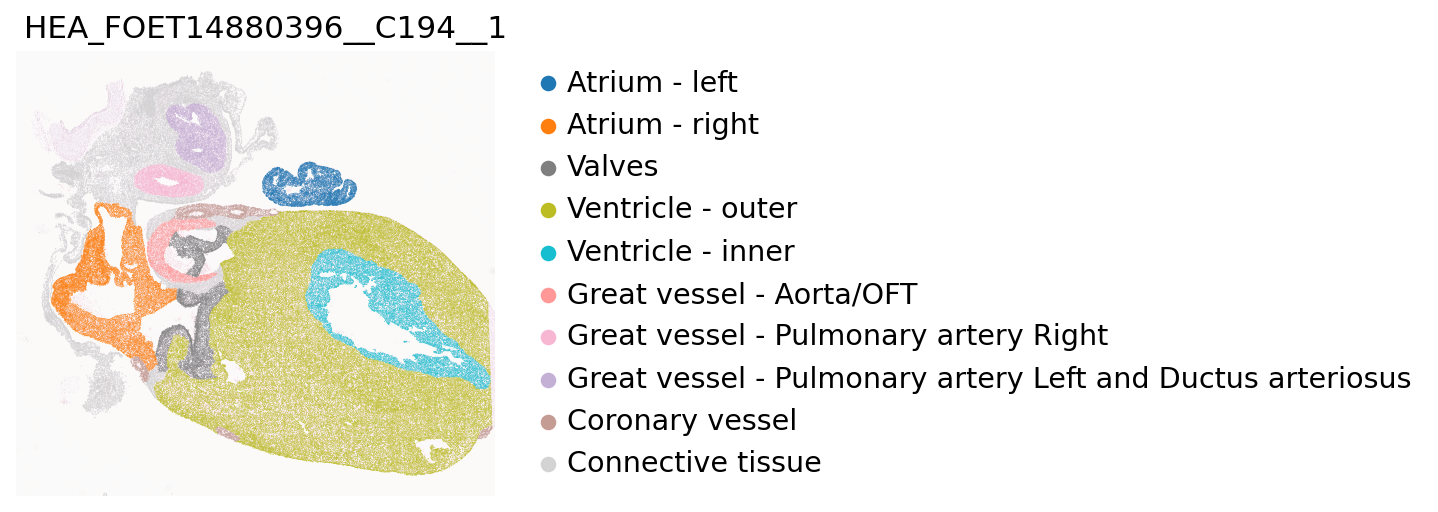

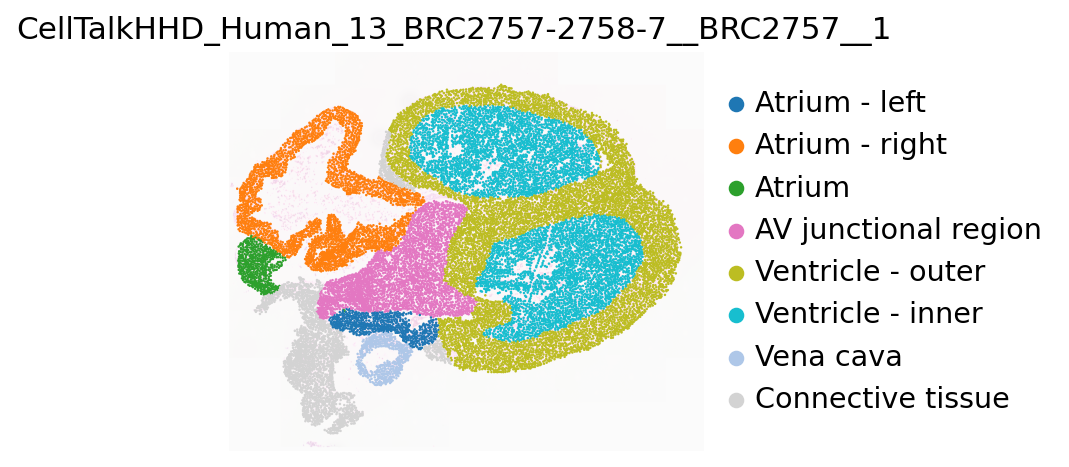

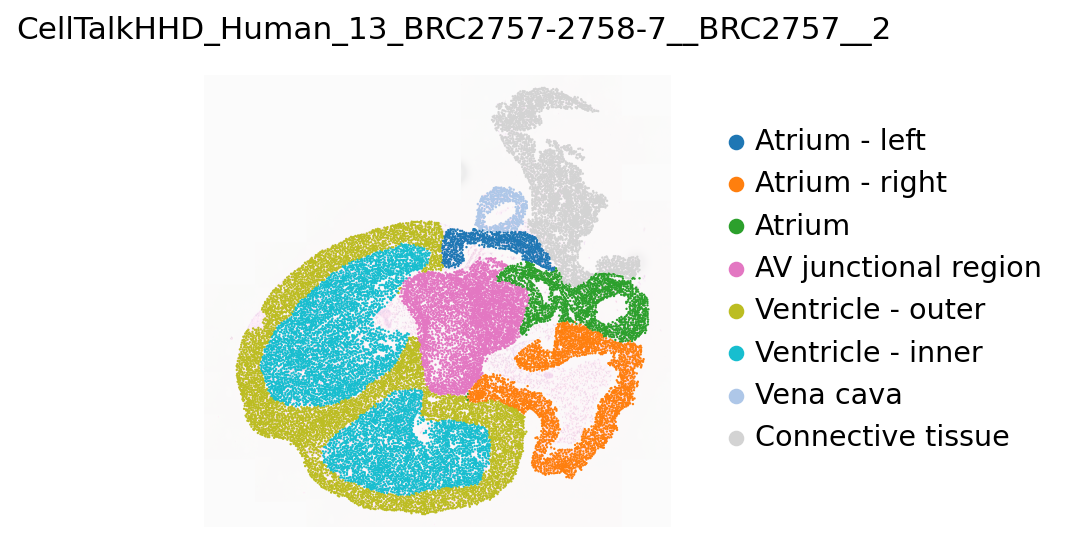

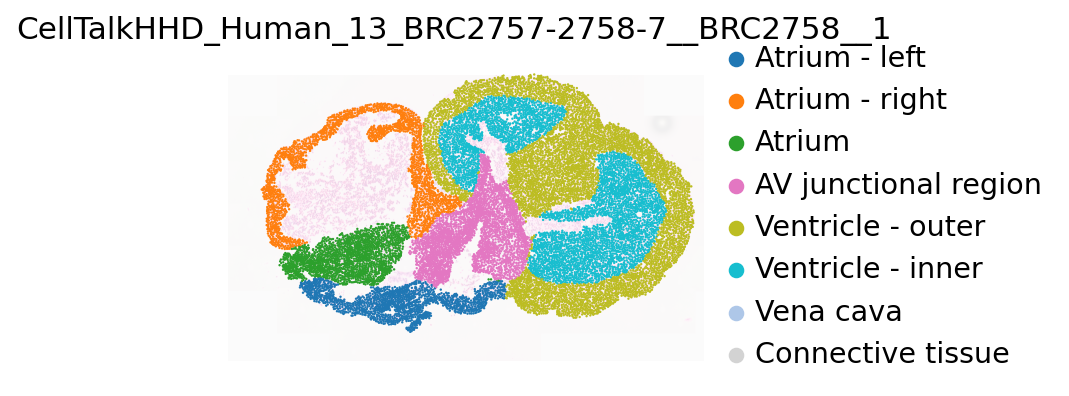

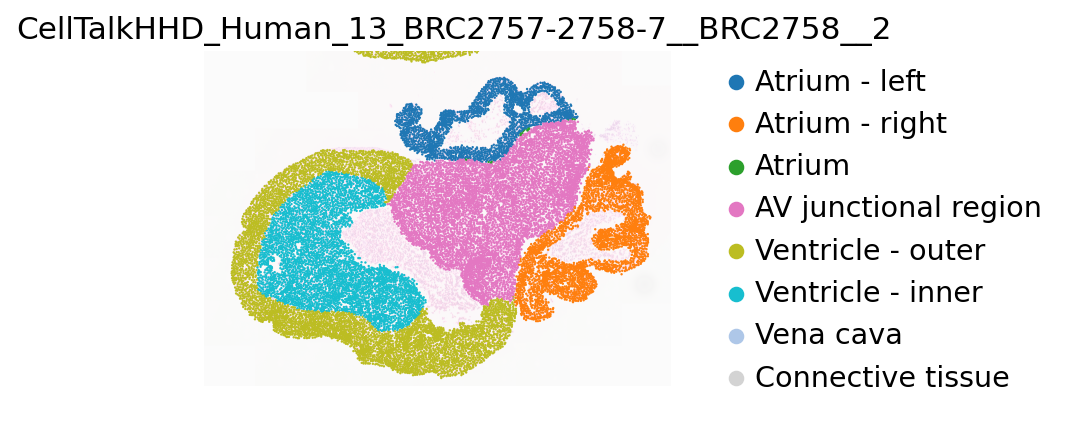

In [17]:
for section_id in section_list:
    mask = adata.obs['section_ID'] == section_id
    library = adata[mask, :].obs['library'].unique()
    if len(library) != 1:
        raise ValueError(f"Expected one library, found: {library}")
    # subsetting
    slide = select_slide(adata, library[0], s_col='library')
    
    if section_id=='HEA_FOET14880396__C194__1':
        spot_size = 50
    else:
        spot_size = 100
    
    sc.pl.spatial(slide, color='HistologicalAnnotation', palette = palette_hist,
                  img_key="0.3_mpp_150_buffer", basis="spatial_cropped_150_buffer",
                  alpha_img=0.2,spot_size=spot_size, frameon=False,
                  title=section_id,crop_coord=crop_coords[section_id],
                  show=False
                 )
    plt.savefig(f'{figdir}/VisiumHD_whole-heart_HistologicalAnnotations_{section_id}.pdf',
                bbox_inches="tight",dpi=300)

# Cross tabulation

In [18]:
obs = adata.obs.copy()
mask1 = obs['niche_fine_Mar2026']!='nan'
mask2 = obs['HistologicalAnnotation'].isin(['non-cardiac tissue','no_annotation'])==False
obs = obs[mask1&mask2].copy()

# Great vessel as single annotation
obs.replace({'HistologicalAnnotation':{
    'Great vessel - Aorta/OFT':'Great vessel',
    'Great vessel - Pulmonary artery Right':'Great vessel',
    'Great vessel - Pulmonary artery Left and Ductus arteriosus':'Great vessel',
}}, inplace=True)

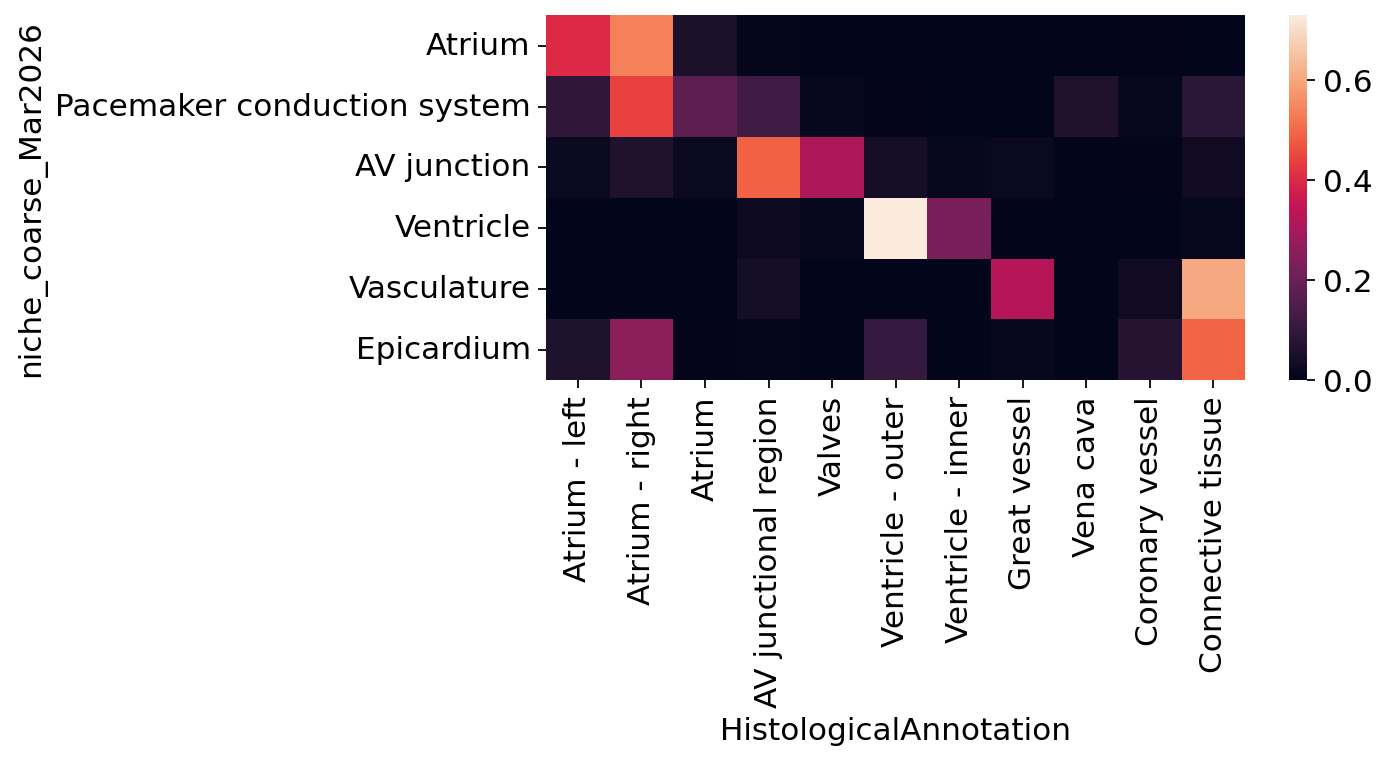

In [21]:
plt.figure(figsize=(7, 3))
df = pd.crosstab(obs['niche_coarse_Mar2026'],
                 obs['HistologicalAnnotation'],
                 normalize='index')
sns.heatmap(df)
plt.grid(False)
plt.show()

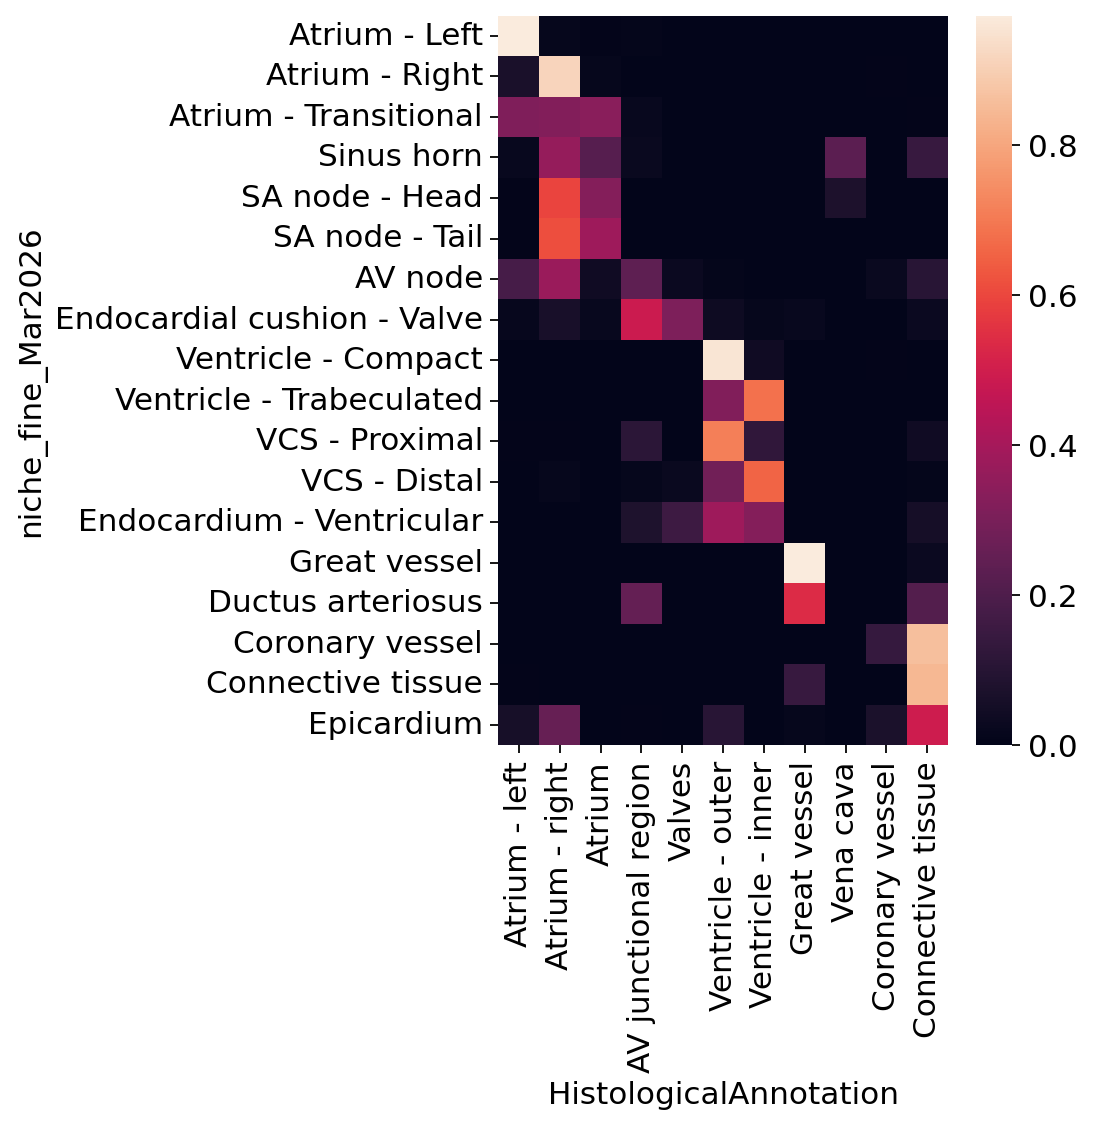

In [23]:
plt.figure(figsize=(4.5, 6))
df = pd.crosstab(obs['niche_fine_Mar2026'],
                 obs['HistologicalAnnotation'],
                 normalize='index')
sns.heatmap(df)
plt.grid(False)
plt.savefig(f'{figdir}/VisiumHD_crosstab_niche-histologicalannot.pdf', bbox_inches="tight",dpi=300)
plt.show()

In [30]:
obs['HistologicalAnnotation'].cat.categories

Index(['Atrium - left', 'Atrium - right', 'Atrium', 'AV junctional region',
       'Valves', 'Ventricle - outer', 'Ventricle - inner', 'Great vessel',
       'Vena cava', 'Coronary vessel', 'Connective tissue'],
      dtype='object')

In [34]:
import pandas as pd
import numpy as np

from sklearn.metrics import cohen_kappa_score, accuracy_score, f1_score, confusion_matrix

# --------------------------------------------------
# Input variables
# --------------------------------------------------

pred_label_arr = obs["niche_fine_Mar2026"].copy()
gt_label_arr = obs['HistologicalAnnotation'].copy()

df = pd.DataFrame({
    "pred_label": pred_label_arr,
    "groundtruth_label": gt_label_arr,
})

# --------------------------------------------------
# 1. Define harmonisation dictionaries
#    Map fine labels to shared anatomical labels
# --------------------------------------------------

pred_to_shared = {
    "Atrium - Left": "Atrium",
    "Atrium - Right": "Atrium",
    "Atrium - Transitional": "Atrium",

    "Sinus horn": "Atrium",
    "SA node - Head": "Atrium",
    "SA node - Tail": "Atrium",

    "AV node": "AV junctional region",
    "AV ring": "AV junctional region",
    "Endocardial cushion - Valve": "AV junctional region",

    "Ventricle - Compact": "Ventricle - Outer",
    "Ventricle - Trabeculated": "Ventricle - Inner",
    "VCS - Proximal": "VCS",
    "VCS - Distal": "VCS",
    # "Endocardium - Atrial": "Atrium",
    "Endocardium - Ventricular": "Ventricle - Inner",
    "Great vessel": "Great vessel",
    "Ductus arteriosus": "Great vessel",
    "Coronary vessel": "Coronary vessel",
    "Connective tissue": "Connective tissue",
    "Epicardium": "Epicardial region",
}

groundtruth_to_shared = {
    'Atrium - left': "Atrium",
    'Atrium - right': "Atrium",
    'Atrium': "Atrium",
    'AV junctional region': "AV junctional region",
    'Valves': "AV junctional region",
    'Ventricle - outer': "Ventricle - Outer",
    'Ventricle - inner': "Ventricle - Inner",
    'Great vessel': "Great vessel",
    'Vena cava': "Vena cava",
    'Coronary vessel': "Coronary vessel",
    'Connective tissue': "Connective tissue"
}

# --------------------------------------------------
# 2. Apply mapping
# --------------------------------------------------

df["pred_shared"] = df["pred_label"].map(pred_to_shared)
df["groundtruth_shared"] = df["groundtruth_label"].map(groundtruth_to_shared)

# Check for unmapped labels
unmapped_pred = sorted(df.loc[df["pred_shared"].isna(), "pred_label"].dropna().unique())
unmapped_groundtruth = sorted(df.loc[df["groundtruth_shared"].isna(), "groundtruth_label"].dropna().unique())

if unmapped_pred:
    print("Unmapped predicted labels:", unmapped_pred)
if unmapped_groundtruth:
    print("Unmapped groundtruth labels:", unmapped_groundtruth)

# Keep only rows where both sides were successfully mapped
df_eval = df.dropna(subset=["pred_shared", "groundtruth_shared"]).copy()

# --------------------------------------------------
# 3. Define evaluation categories (clean + ordered)
# --------------------------------------------------

# All possible shared categories (order defined by pred_to_shared)
all_categories = list(dict.fromkeys(pred_to_shared.values()))

# Categories actually present after mapping
pred_present = set(df_eval["pred_shared"].unique())
gt_present = set(df_eval["groundtruth_shared"].unique())

# Report missing categories
missing_in_pred = set(all_categories) - pred_present
missing_in_gt = set(all_categories) - gt_present

print("All categories (ordered):", all_categories)
print("Missing in predictions:", sorted(missing_in_pred))
print("Missing in groundtruth:", sorted(missing_in_gt))

# Evaluation categories = ordered intersection
eval_categories = [c for c in all_categories if c in pred_present and c in gt_present]

print("Evaluation categories (used for metrics):", eval_categories)
print("n categories (all):", len(all_categories))
print("n categories (evaluated):", len(eval_categories))

# Restrict dataset to evaluation categories only
df_eval = df_eval[
    df_eval["pred_shared"].isin(eval_categories) &
    df_eval["groundtruth_shared"].isin(eval_categories)
].copy()

# Enforce categorical dtype to keep order stable
df_eval["pred_shared"] = pd.Categorical(
    df_eval["pred_shared"],
    categories=eval_categories,
    ordered=True
)
df_eval["groundtruth_shared"] = pd.Categorical(
    df_eval["groundtruth_shared"],
    categories=eval_categories,
    ordered=True
)

# --------------------------------------------------
# 4. Compute metrics
# --------------------------------------------------

y_true = df_eval["groundtruth_shared"].astype(str)
y_pred = df_eval["pred_shared"].astype(str)

kappa = cohen_kappa_score(y_true, y_pred)
acc = accuracy_score(y_true, y_pred)
macro_f1 = f1_score(y_true, y_pred, average="macro")
micro_f1 = f1_score(y_true, y_pred, average="micro")

print(f"Cohen's kappa: {kappa:.4f}")
print(f"Accuracy:      {acc:.4f}")
print(f"Macro F1:      {macro_f1:.4f}")
print(f"Micro F1:      {micro_f1:.4f}")

# --------------------------------------------------
# 5. Confusion matrix / cross-tab
# --------------------------------------------------

cm = confusion_matrix(y_true, y_pred, labels=eval_categories)
cm_df = pd.DataFrame(cm, index=eval_categories, columns=eval_categories)

print("\nConfusion matrix:")
print(cm_df)

# Row-normalised version (true groundtruth rows sum to 1)
cm_row_norm = cm_df.div(cm_df.sum(axis=1).replace(0, np.nan), axis=0)

print("\nRow-normalised confusion matrix:")
print(cm_row_norm)

# --------------------------------------------------
# 6. Permutation test for kappa
# --------------------------------------------------

from tqdm import tqdm
import numpy as np
from sklearn.metrics import cohen_kappa_score

def permutation_test_kappa(y_true, y_pred, n_perm=1000, random_state=0, show_progress=True):
    rng = np.random.default_rng(random_state)

    observed = cohen_kappa_score(y_true, y_pred)
    permuted = np.empty(n_perm)

    y_pred = np.asarray(y_pred)

    iterator = range(n_perm)
    if show_progress:
        iterator = tqdm(iterator, desc="Permutation test (kappa)")

    for i in iterator:
        y_pred_perm = rng.permutation(y_pred)
        permuted[i] = cohen_kappa_score(y_true, y_pred_perm)

    # one-sided p-value: how often permuted >= observed
    p_value = (np.sum(permuted >= observed) + 1) / (n_perm + 1)

    return observed, permuted, p_value

obs_kappa, perm_kappas, p_perm = permutation_test_kappa(
    y_true,
    y_pred,
    n_perm=1000,
    random_state=42
)

print("\nPermutation test for kappa:")
print(f"Observed kappa = {obs_kappa:.4f}")
print(f"P-value        = {p_perm:.6f}")

All categories (ordered): ['Atrium', 'AV junctional region', 'Ventricle - Outer', 'Ventricle - Inner', 'VCS', 'Great vessel', 'Coronary vessel', 'Connective tissue', 'Epicardial region']
Missing in predictions: []
Missing in groundtruth: ['Epicardial region', 'VCS']
Evaluation categories (used for metrics): ['Atrium', 'AV junctional region', 'Ventricle - Outer', 'Ventricle - Inner', 'Great vessel', 'Coronary vessel', 'Connective tissue']
n categories (all): 9
n categories (evaluated): 7
Cohen's kappa: 0.7554
Accuracy:      0.8116
Macro F1:      0.7011
Micro F1:      0.8116

Confusion matrix:
                      Atrium  AV junctional region  Ventricle - Outer  \
Atrium                 24308                  5966                  0   
AV junctional region     189                 15859                  1   
Ventricle - Outer          0                   709              59693   
Ventricle - Inner          0                   201               2587   
Great vessel               0        

Permutation test (kappa): 100%|██████████| 1000/1000 [08:38<00:00,  1.93it/s]


Permutation test for kappa:
Observed kappa = 0.7554
P-value        = 0.000999
